# Agentic forecasting step-by-step

**skforecast-ai** is an **AI forecasting assistant** that pairs a deterministic engine, powered by [**skforecast**](https://skforecast.org), with an **LLM reasoning layer**. Simply provide a time series, and the assistant automatically profiles the data, selects a model using established best practices, and evaluates its performance. It returns both the final forecast and the runnable skforecast script that produced it.

This tutorial walks through the **step-by-step path**: the approach for users who want granular control to inspect or adjust intermediate decisions before committing to a full run. If you prefer a single-call workflow that returns results immediately, see the [fast-path tutorial](./agentic-forecasting-with-skforecast-ai.ipynb).

Both paths share the same deterministic engine and produce identical results and reproducible `skforecast` code. The step-by-step path gives you three additional capabilities:

+ **Inspect intermediate objects**: examine the `ForecastingProfile` and `ForecastPlan` before any model is trained, and confirm the assistant's recommendations make sense for your domain.

+ **Override any single decision**: change the estimator, lags, window features, or preprocessing without re-running the entire pipeline from scratch. Pass the modified plan directly to `forecast()` or `backtest()`.

+ **Reuse the profile and plan across branches**: build the profile and plan once, then run `forecast()` for future predictions and `backtest()` for historical evaluation: each reusing the same profile, with no redundant profiling.

The `ask()` method is available at every stage. It interprets what you pass to it (a profile, a plan, a forecast result, or a backtest result), but it never executes the workflow or silently changes any recommendation.

<div style="box-sizing:border-box; margin:16px 0; font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; color:#24292f; max-width:100%;">
  <div style="box-sizing:border-box; display:flex; gap:20px; flex-wrap:wrap; align-items:stretch;">

<!-- Fast path -->
<div style="box-sizing:border-box; flex:1 1 260px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#0969da; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Fast path: one call</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Profiling, planning and execution happen internally.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:18px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

<!-- Step-by-step path -->
<div style="box-sizing:border-box; flex:1.6 1 340px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#1a7f37; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Step-by-step path: full control</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Build a <code>profile</code> and a <code>plan</code> from your data, then branch into forecasting and backtesting.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:8px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">profile()</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">plan()<br><span style="font-weight:400; font-size:12px; color:#57606a;">refine_plan(), optional (Deterministic or Agentic mode)</span></div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

  </div>

  <!-- ask() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #8250df; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#8250df; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">LLM reasoning: available at any moment, in any workflow</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#faf5ff; font-size:13px;">Call <code>ask()</code> before, during or after either path. It can take a <code>profile</code>, a <code>plan</code>, a <code>forecast_result</code>, a <code>backtest_result</code>, or nothing at all (pure Q&amp;A).</div>
  </div>
</div>

The following example walks through the **step-by-step** allowing user to understand and control what happens under the hood. If you prefer the quickest way to go from raw data to a validated forecast with minimal setup, visit the [fast path tutorial](./agentic-forecasting.html).

## Assistant initialization

The first step is to instantiate a `ForecastingAssistant`, which will be responsible for executing the entire workflow (profiling, planning, backtesting, and forecasting), as well as explaining the outputs and suggesting improvements.

To activate the optional LLM support, users must pass a string in the format `'provider:model_name'` (for example, `'openai:gpt-5.5'`, `'google:gemini-3-flash-preview'`, `'anthropic:claude-sonnet-5'`, or `'ollama:qwen3:8b'`). For hosted providers, the corresponding API key must be available as an environment variable or passed explicitly when creating the assistant. In this tutorial, we set `send_data_to_llm=False`. This ensures strict data privacy: the LLM receives only metadata and summary statistics, never the raw time series values.

In [1]:
# Data processing
# ==============================================================================
import os
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# skforecast and skforecast-ai
# ==============================================================================
import skforecast
import skforecast_ai
from skforecast_ai import ForecastingAssistant
from skforecast.model_selection import TimeSeriesFold
from skforecast.plot import set_dark_theme

# Python utilities
# ==============================================================================
import textwrap

color = '\033[1m\033[38;5;208m'
print(f"{color}Version skforecast_ai: {skforecast_ai.__version__}")
print(f"{color}Version skforecast: {skforecast.__version__}")

Version skforecast_ai: 0.1.0
Version skforecast: 0.23.0


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    If you do not have access to an LLM, you can still follow the full tutorial using only the deterministic methods. Profiling, planning, backtesting, and forecasting all run without an LLM. Only the <code>ask()</code> explanations and the LLM-guided variants of <code>refine_plan()</code> and <code>create_cv()</code> require a configured LLM; their deterministic counterparts work without one.
  </p>

</div>

In [ ]:
# LLM-enabled assistant
# ==============================================================================
LLM_MODEL = "google:gemini-2.5-flash"
api_key = os.getenv("GOOGLE_API_KEY")

assistant = ForecastingAssistant(
    llm=LLM_MODEL, api_key=api_key, send_data_to_llm=False
)

# Using AWS Bedrock
# ==============================================================================
# assistant = ForecastingAssistant(
#     llm='bedrock:eu.anthropic.claude-sonnet-4-6',
#     base_url="eu-west-1"
# )

# Assistant without LLM (deterministic only)
# ==============================================================================
# assistant = ForecastingAssistant()

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Your data stays private</strong>
</p>

<p>
By default, enabling an LLM does not send your time-series data to the model provider.
The assistant passes only summary statistics, detected frequency,
seasonality flags and the forecaster configuration, never the raw observations.
To explicitly allow it, pass <code>send_data_to_llm=True</code>.
</p>

</div>

## Data

The data used in this tutorial represent the hourly usage of the bike share system in the city of Washington, D.C. during the years 2011 and 2012. In addition to the number of users per hour, information about weather conditions and holidays is available.

In [3]:
# Downloading data
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]
data['date_time'] = pd.to_datetime(data['date_time'])
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users,holiday,weather,temp
0,2011-01-01 00:00:00,16.0,0.0,clear,9.84
1,2011-01-01 01:00:00,40.0,0.0,clear,9.02
2,2011-01-01 02:00:00,32.0,0.0,clear,9.02
3,2011-01-01 03:00:00,13.0,0.0,clear,9.84
4,2011-01-01 04:00:00,1.0,0.0,clear,9.84


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    <code>skforecast-ai</code> is ready to preprocess the data, but it is recommended that users apply their own preprocessing steps before using the assistant. This ensures the data is in the desired format and any necessary transformations have been applied before proceeding with the forecasting workflow.
  </p>

</div>

In [4]:
# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=data['date_time'], y=data['users'], mode='lines', name='Users')
)
fig.update_layout(
    title  = 'Number of users',
    xaxis_title="Time",
    yaxis_title="Users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
fig.show()

For a deeper walkthrough of the exploratory analysis behind this dataset, see the skforecast example: [Forecasting time series with skforecast, XGBoost, LightGBM and CatBoost](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost#Data_exploration).

## Profile the data

The `profile()` method is the first stage of the step-by-step workflow. It inspects the dataset and returns a `ForecastingProfile` object that contains:

+ **Data metadata**: detected frequency, index type, series lengths, missing values, and exogenous column roles.

+ **Modeling recommendations**: the selected forecaster family and estimator, along with alternative candidates and the reasoning behind each choice.

+ **Lag structure**: PACF-significant lags per series, used as a baseline for the planning stage.

+ **Window feature suggestions**: rolling statistics configurations appropriate for the detected seasonality.

This is a purely deterministic step: no LLM is involved. The `profile` object is a prerequisite for both `plan()` and `ask()` explain mode.

| Attribute | Description |
|---|---|
| `data_profile` | Full dataset metadata: frequency, index type, series lengths, missing values, exog columns |
| `forecaster` | Recommended skforecast forecaster class name |
| `forecaster_candidates` | Ordered list of compatible forecaster names |
| `estimator` | Recommended estimator class name (None for statistical models) |
| `estimator_candidates` | Ordered list of compatible estimator names |
| `series_pacf` | Per-series PACF-significant lags (used by `plan()` to set default lags) |
| `window_features` | Suggested window feature configurations |
| `calendar_features` | Recommended calendar feature names based on detected seasonality |
| `explanation` | Human-readable explanation of why this forecaster and estimator were selected |

In [5]:
# Profile the data
# ==============================================================================
profile = assistant.profile(
    data        = data,
    target      = 'users',
    date_column = 'date_time'
)

In [6]:
# Inspect the profile
# ==============================================================================
profile

              Dataset Profile              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                 │
├────────────────┼────────────────────────┤
│ Series         │ 1                      │
├────────────────┼────────────────────────┤
│ Observations   │ 17544                  │
├────────────────┼────────────────────────┤
│ Frequency      │ h                      │
├────────────────┼────────────────────────┤
│ Target         │ users                  │
├────────────────┼────────────────────────┤
│ Exog columns   │ holiday, weather, temp │
├────────────────┼────────────────────────┤
│ Missing target │ none                   │
└────────────────┴────────────────────────┘

                                      Recommendation                                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                                  │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                            │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation,   │
│                       │ ForecasterStats                                                │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                                  │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                             │
└───────────────────────┴────────────────────────────────────────────────────────────────┘

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation', 'ForecasterStats']. Estimator: LGBMRegressor. A gradient      │
│  boosting model is preferred for a dataset of this size (17544 observations).          │
│  Alternative estimators: ['XGBRegressor', 'Ridge']. 3 exogenous variables available    │
│  as predictors.                                                                        │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Once you have a profile, you can pass it to `ask()` to get an LLM-generated explanation of the modeling decisions. Note that the pre-computed `profile` is passed directly, so no profiling work is repeated.

In [7]:
# Ask the assistant to explain the profile
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Explain why this forecaster and estimator were recommended for my "
        "hourly bike-sharing demand data, and what the exogenous variables add."
    ),
    profile = profile,
    steps   = 36,
)
answer.show_explanation()

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│                Forecasting Plan Explanation: Hourly Bike-Sharing Demand                │
│                                                                                        │
│  Why ForecasterRecursive?                                                              │
│                                                                                        │
│  ForecasterRecursive is the natural starting point for a single time series of this    │
│  size. With 17,544 hourly observations (roughly 2 years of data), you have enough      │
│  history to train a robust ML model. The recursive strategy uses one model that feeds  │
│  its own predictions forward through the 36-step horizon, which is efficient and       │
│  well-suited to a medium-length horizon like 36 hours.                                 │
│                                                                                        │
│  The alternative, ForecasterDirect, would train 36 separate models (one per hour       │
│  ahead). That is worth exploring if you find that the relationship between past usage  │
│  and future demand changes substantially depending on how far ahead you're predicting  │
│  — for example, if 1-hour-ahead patterns differ sharply from 24-hour-ahead patterns.   │
│  It is listed as an alternative precisely for that reason.                             │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Why LightGBM (LGBMRegressor)?                                                         │
│                                                                                        │
│  LightGBM is the preferred estimator here for several reasons:                         │
│                                                                                        │
│   • Dataset size: ~17,500 rows is the sweet spot where gradient boosting outperforms   │
│     simpler models (Ridge) without needing deep learning.                              │
│   • Mixed feature types: Your feature set mixes lags (continuous), calendar features   │
│     (ordinal), and exogenous variables including categoricals like holiday. LightGBM   │
│     handles this natively with its histogram-based splitting.                          │
│   • NaN tolerance: Some lag/window features will be NaN at the start of the series     │
│     (the "warm-up" period). LightGBM can train through NaN rows without requiring      │
│     imputation, so dropna_from_series=False is used — no data is wasted.               │
│   • Speed and accuracy: LightGBM trains fast and typically achieves lower error than   │
│     Random Forest or XGBoost on tabular time series data of this kind.                 │
│                                                                                        │
│  XGBRegressor and Ridge are listed as alternatives — Ridge is worth trying as a        │
│  linear baseline, while XGBoost is a close competitor to LightGBM.                     │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Why These Lags?                                                                       │
│                                                                                        │
│  The lag selection reflects the natural cycles in hourly bike-sharing demand:          │
│                                                                                      

## Build the plan

The `plan()` method converts the coarse modeling decisions in the `ForecastingProfile` into a fully-specified, executable configuration. It determines:

+ **Lags**: derived from the PACF-significant lags detected in the profile. You can override these explicitly.
+ **Window features**: rolling statistics configurations appropriate for the detected seasonality.
+ **Preprocessing steps**: ordered list of transformations (e.g., differencing, scaling, NaN handling).
+ **Prediction interval method**: `'bootstrapping'`, `'conformal'`, or `'native'` (selected based on the estimator).
+ **Metrics**: the primary and secondary evaluation metrics.

Like `profile()`, this is a deterministic step. The resulting `ForecastPlan` object is the complete blueprint that `forecast()` and `backtest()` execute.

| Attribute | Description |
|---|---|
| `forecaster` | Forecaster class name |
| `estimator` | Estimator class name |
| `forecaster_kwargs` | All constructor kwargs for the forecaster, including `lags` and `window_features` |
| `estimator_kwargs` | Constructor kwargs for the estimator |
| `steps` | Forecast horizon |
| `interval` | Prediction interval quantiles, e.g. `[0.1, 0.9]` |
| `interval_method` | Method used to produce the interval (`bootstrapping`, `conformal`, or `native`) |
| `use_exog` | Whether exogenous variables are included |
| `preprocessing_steps` | Ordered list of preprocessing actions with code snippets |
| `explanation` | Human-readable explanation of plan decisions |

In [8]:
# Build a plan from the profile
# ==============================================================================
plan = assistant.plan(
    profile  = profile,
    steps    = 36,
    interval = [0.1, 0.9]  # 80% prediction interval
)

In [9]:
# Inspect the plan
# ==============================================================================
plan

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32,    │
│                   │ 33, 119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169, 313,    │
│                   │ 335, 337]                                                          │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ none                                                               │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 5, 8, 10, 15, 17, 19, 20,  │
│  21, 22, 23, 24, 25, 26, 32, 33, 119, 121, 135, 136, 142, 143, 145, 160, 166, 167,     │
│  169, 313, 335, 337]. Window features: ['mean(window=3)', 'std(window=3)',             │
│  'mean(window=24)', 'mean(window=168)']. Calendar features: ['hour', 'day_of_week',    │
│  'weekend', 'month'] (raw ordinal encoding). Prediction intervals via bootstrapping.   │
│  NaN rows kept (NaN-tolerant estimator). Exogenous variables included. MAE is          │
│  interpretable, robust to outliers, and works at any scale.                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Pass both the `profile` and the `plan` to `ask()` for a detailed explanation of the chosen configuration.

In [10]:
# Ask the assistant to explain the plan
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Walk me through this plan. Why these lags and window features, "
        "and how will the 80% prediction interval be produced?"
    ),
    profile = profile,
    plan    = plan,
)
answer.show_explanation()

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│                               Forecast Plan Walkthrough                                │
│                                                                                        │
│  Overview                                                                              │
│                                                                                        │
│  The plan uses ForecasterRecursive + LGBMRegressor to forecast 36 hours ahead on a     │
│  single hourly series (users) with three exogenous variables (holiday, weather,        │
│  temp). Here is what each design choice means and why it was made.                     │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Lag Selection                                                                         │
│                                                                                        │
│  The 32 selected lags split into three distinct groups, each capturing a different     │
│  temporal pattern:                                                                     │
│                                                                                        │
│  Short-range lags (1–33)                                                               │
│                                                                                        │
│  [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32, 33]                   │
│                                                                                        │
│  These capture recent autocorrelation — how the last few hours influence the next.     │
│  Lags 23–26 are particularly important because they straddle the same hour yesterday   │
│  (lag 24), giving the model a direct "what was happening at this time 24 hours ago"    │
│  signal. Lags 32–33 reach about 1.3 days back.                                         │
│                                                                                        │
│  Weekly-cycle lags (~120–169)                                                          │
│                                                                                        │
│  [119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169]                               │
│                                                                                        │
│  These cluster around lag 120 (5 days) and lag 168 (exactly one week). Hourly user     │
│  data almost always has a strong weekly seasonality — the model learns "what was       │
│  happening at this hour on similar days last week." The lags slightly above and below  │
│  168 (166, 167, 169) let the model handle weekly patterns that are not perfectly       │
│  rigid.                                                                                │
│                                                                                        │
│  Two-week lag (~313–337)                                                               │
│                                                                                        │
│  [313, 335, 337]                                                                       │
│                                                                                        │
│  These reach back approximately two weeks (~336 hours), reinforcing the fortnightly    │
│  cycle that appears in many usage patterns (e.g., bi-weekly events or payroll          │
│  cycles).                                                                              │
│                                                                                      

## Refine the plan (optional)

The `refine_plan()` method lets you adjust the plan before execution. It operates in two distinct modes:

+ **Deterministic mode** (`prompt=None`): pass explicit configuration overrides such as `lags`, `estimator`, `estimator_kwargs`, `forecaster`, `steps`, `interval`, or `window_features`. Only the fields you explicitly specify are updated; the rest of the configuration is deterministically re-derived from the original plan.

+ **LLM mode** (`prompt` provided): describe your domain knowledge in natural language. The LLM interprets this context and suggests appropriate `lags` and `window_features`. Its reasoning is appended to `plan.explanation` and the changed fields are recorded in `plan.llm_refined_fields` for full traceability.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>A refined plan is a <strong>hypothesis, not a guaranteed improvement</strong>. The LLM may propose lags or window features that are not helpful for the series, or it may misread the domain context you provided. Always compare the refined plan against the original baseline using a proper backtest over multiple folds before adopting it.</p>

</div>

### Deterministic mode

In [11]:
# Refine the plan with explicit overrides (no LLM required)
# ==============================================================================
plan_det = assistant.refine_plan(
    profile          = profile,
    plan             = plan,
    lags             = [1, 2, 3, 24, 48, 168],
    estimator_kwargs = {'n_estimators': 200, 'max_depth': 6}
)
plan_det

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 24, 48, 168]                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ none                                                               │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 24, 48, 168]. Window       │
│  features: ['mean(window=3)', 'std(window=3)', 'mean(window=24)',                      │
│  'mean(window=168)']. Calendar features: ['hour', 'day_of_week', 'weekend', 'month']   │
│  (raw ordinal encoding). Prediction intervals via bootstrapping. NaN rows kept         │
│  (NaN-tolerant estimator). Exogenous variables included. MAE is interpretable, robust  │
│  to outliers, and works at any scale.                                                  │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### LLM mode

In [12]:
# Refine the plan using LLM-guided domain knowledge
# ==============================================================================
prompt = (
    "I'm forecasting hourly bike rentals. Demand follows a clear daily rhythm with "
    "rush-hour peaks, and it changes between weekdays and weekends. It's also usually "
    "similar to what happened at the same time last week, and the last few hours give "
    "a good sense of the current trend. Please pick lags and rolling features that fit this."
)

plan_refined = assistant.refine_plan(
    profile = profile,
    plan    = plan,
    prompt  = prompt
)

In [13]:
# Refined plan proposed by the assistant
# ==============================================================================
plan_refined

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 4, 5, 6, 23, 24, 25, 47, 48, 49, 167, 168, 169]          │
│                   │ (LLM-suggested)                                                    │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 24}, {'stats': ['mean', │
│                   │ 'max'], 'window_size': 168}]  (LLM-suggested)                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ none                                                               │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 4, 5, 6, 23, 24, 25, 47,   │
│  48, 49, 167, 168, 169]. Window features: ['mean(window=24)', 'std(window=24)',        │
│  'mean(window=168)', 'max(window=168)']. Calendar features: ['hour', 'day_of_week',    │
│  'weekend', 'month'] (raw ordinal encoding). Prediction intervals via bootstrapping.   │
│  NaN rows kept (NaN-tolerant estimator). Exogenous variables included. MAE is          │
│  interpretable, robust to outliers, and works at any scale.                            │
│                                                                                        │
│  LLM Refinement Reasoning: Lags chosen:                                                │
│                                                                                        │
│   1 Recent trend (lags 1–6): The user notes that "the last few hours give a good       │
│     sense of the current trend." Lags 1–6 capture the immediate short-term momentum    │
│     (e.g., a demand ramp-up or cool-down around rush hour), giving the model a windo

### Explain mode (refined plan)

In [14]:
# Ask the assistant what changed and why
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "What changed in the refined plan compared to the original, "
        "and why does it matter for this dataset?"
    ),
    profile = profile,
    plan    = plan_refined,
)
answer.show_explanation()

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│               Refined Plan vs. Original: What Changed and Why It Matters               │
│                                                                                        │
│  Overview of Changes                                                                   │
│                                                                                        │
│  The refinement made two targeted adjustments to the default configuration: expanded   │
│  lag selection and enriched window features. Both changes are motivated by the         │
│  specific temporal structure of an hourly bike-sharing dataset.                        │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  1. Lag Selection                                                                      │
│                                                                                        │
│  What changed                                                                          │
│                                                                                        │
│  A generic default might use a simple contiguous block (e.g., lags 1–24). The refined  │
│  plan uses a sparse, seasonality-aware set:                                            │
│                                                                                        │
│                                                                                        │
│   Group                Lags              Rationale                                     │
│   ────────────────────────────────────────────────────────────────────                 │
│   Recent trend         1, 2, 3, 4, 5, 6  Immediate short-term momentum                 │
│   Yesterday (±1 h)     23, 24, 25        Same hour the prior day                       │
│   Two days ago (±1 h)  47, 48, 49        Second daily anchor                           │
│   Last week (±1 h)     167, 168, 169     Same hour last week                           │
│                                                                                        │
│                                                                                        │
│  Why it matters for this dataset                                                       │
│                                                                                        │
│  Bike rentals are driven by two overlapping seasonal cycles — daily commuter patterns  │
│  (rush hours, lunch) and weekly patterns (weekday vs. weekend behaviour). Using lags   │
│  at 24 and 168 hours directly encodes these cycles without forcing the model to        │
│  reconstruct them from a dense contiguous block. The ±1 hour buffer around each        │
│  anchor (e.g., 23/24/25 rather than just 24) makes the model robust to small timing    │
│  shifts in when peaks actually occur, day to day.                                      │
│                                                                                        │
│  Including lags 1–6 alongside the seasonal anchors means the model can simultaneously  │
│  track where you are in a pattern right now (the current ramp-up or wind-down) and     │
│  what that same moment looked like historically.                                       │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  2. Window Features                                                                  

## Forecast

Once you have a `profile` and a `plan`, you can call `forecast()` or `forecast_code()`. Both accept the pre-computed `profile` and `plan` so no additional profiling is performed. The `forecast()` method executes the generated script and returns a `ForecastResult`; `forecast_code()` generates the script only, without running it.

The forecast branch operates in two modes:

+ **Evaluation mode** (`test_size` is set): the dataset is split into train and test sets, the model is trained on the train portion, and predictions are compared against the held-out actuals to compute metrics.

+ **Prediction mode** (`test_size=None`, the default): the model is trained on the entire dataset and forecasts the next `steps` time points into the future. Because there is no ground truth, no metrics are returned. If the data has exogenous variables, their future values must be supplied via `exog`.

### Evaluation mode

In [15]:
# Forecast in evaluation mode, reusing the pre-computed profile and plan
# ==============================================================================
results_eval = assistant.forecast(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    interval    = [0.1, 0.9],  # 80% prediction interval
    test_size   = 36,          # Last 36 hours as test set
    profile     = profile,     # Reuse the pre-computed profile
    plan        = plan_refined # Reuse the refined plan
)

display(results_eval.metrics)
display(results_eval.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /home/ubuntu/miniconda3/envs/skforecast_ai/lib/python3.13/site-packages/skforecast_a │
│ i/_utils.py:392                                                                      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,series,MAE,MSE,MASE,MAPE
0,users,40.923829,3810.711588,0.63557,0.488009


,pred,lower_bound,upper_bound
2012-12-30 12:00:00,146.245548,110.543227,181.414944
2012-12-30 13:00:00,136.316434,93.000437,170.402002
2012-12-30 14:00:00,129.139815,90.684704,164.117185
2012-12-30 15:00:00,132.205230,91.023046,171.324095
2012-12-30 16:00:00,136.448864,87.288046,173.381217


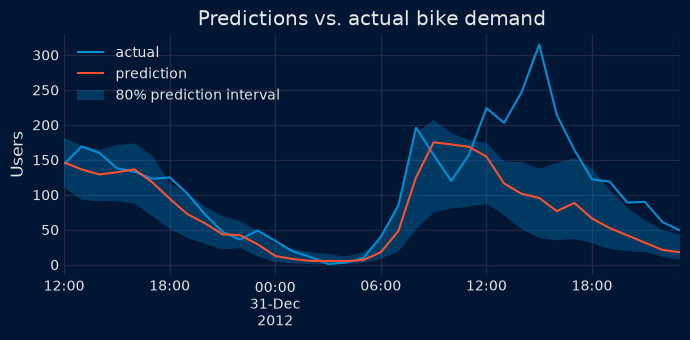

In [16]:
# Plot predictions vs. actual values for the held-out test period
# ==============================================================================
set_dark_theme()
preds = results_eval.predictions
fig, ax = plt.subplots(figsize=(7, 3.5))
data.set_index('date_time').loc[preds.index, 'users'].plot(ax=ax, label='actual')
preds['pred'].plot(ax=ax, label='prediction')
if {'lower_bound', 'upper_bound'}.issubset(preds.columns):
    ax.fill_between(
        preds.index, preds['lower_bound'], preds['upper_bound'],
        alpha=0.3, label='80% prediction interval'
    )
ax.set_title('Predictions vs. actual bike demand')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Ask the assistant to interpret the forecast results
# ==============================================================================
answer = assistant.ask(
    prompt          = "Explain the results of this forecast, including the metrics and predictions.",
    forecast_result = results_eval
)
answer.show_explanation()

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│                              Forecast Results Explanation                              │
│                                                                                        │
│  Overview                                                                              │
│                                                                                        │
│  The model forecasts 36 hours of hourly bike rental demand (users) from 2012-12-30     │
│  12:00 through 2012-12-31 23:00, using a ForecasterRecursive with LightGBM and a rich  │
│  set of lag and rolling features.                                                      │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│                                                                                        │
│   Metric  Value    Interpretation                                                      │
│   ──────────────────────────────────────────────────────────────────────────────────   │
│   MAE     40.92    On average, predictions are off by ~41 users per hour               │
│   MSE     3,810.7  Elevated by occasional larger errors; less interpretable directly   │
│   MASE    0.636    Better than naive by ~36% — a strong result                         │
│   MAPE    0.488    ~49% average percentage error                                       │
│                                                                                        │
│                                                                                        │
│  Key takeaways on metrics                                                              │
│                                                                                        │
│   • MASE of 0.636 is the headline result. Since MASE < 1 means the model outperforms   │
│     a naïve "same value as last period" baseline, a score of 0.636 confirms the model  │
│     adds genuine predictive value — it is roughly 36% more accurate than simply        │
│     repeating the previous observation.                                                │
│   • MAE of ~41 users is interpretable in absolute terms. Whether this is acceptable    │
│     depends on the operating context (e.g., if peak demand reaches ~175 users, an      │
│     error of 41 represents about 23% of peak).                                         │
│   • MAPE of ~49% appears high, but this is common with bike rental data. MAPE          │
│     inflates during low-demand hours (late night, when the denominator is very small   │
│     — e.g., 5–20 users). It is less reliable here than MAE or MASE.                    │
│   • MSE of 3,811 suggests the model makes some notably larger errors at certain        │
│     hours, likely around demand peaks or transitions (rush hours), where the           │
│     recursive multi-step propagation of small errors compounds.                        │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Prediction Patterns                                                                   │
│                                                                                        │
│  2012-12-30 afternoon (start of horizon)                                             

### Prediction mode

In prediction mode, the model trains on the entire dataset and forecasts the next `steps` time points. Because the data includes exogenous variables (`holiday`, `weather`, `temp`), their future values must be supplied via the `exog` argument.

In [18]:
# Forecast the next 36 hours using the entire dataset (prediction mode)
# ==============================================================================
# Simulate future values of exogenous variables for the next 36 hours
exog = data[['holiday', 'weather', 'temp']].tail(36).copy()
exog.index = pd.date_range(
    start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(hours=1),
    periods=36,
    freq='h'
)

results_pred = assistant.forecast(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,        # Use the entire dataset (prediction mode)
    exog        = exog,        # Future values of exogenous variables
    profile     = profile,
    plan        = plan_refined
)

display(results_pred.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /home/ubuntu/miniconda3/envs/skforecast_ai/lib/python3.13/site-packages/skforecast_a │
│ i/_utils.py:392                                                                      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,pred,lower_bound,upper_bound
2013-01-01 00:00:00,23.710329,14.499605,34.620105
2013-01-01 01:00:00,13.736574,4.459790,22.583204
2013-01-01 02:00:00,8.889456,2.781534,18.004651
2013-01-01 03:00:00,6.263093,1.728842,12.564202
2013-01-01 04:00:00,6.263093,1.615673,12.644115


In [19]:
# Full results object
# ==============================================================================
results_pred

              Dataset Profile              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                 │
├────────────────┼────────────────────────┤
│ Series         │ 1                      │
├────────────────┼────────────────────────┤
│ Observations   │ 17544                  │
├────────────────┼────────────────────────┤
│ Frequency      │ h                      │
├────────────────┼────────────────────────┤
│ Target         │ users                  │
├────────────────┼────────────────────────┤
│ Exog columns   │ holiday, weather, temp │
├────────────────┼────────────────────────┤
│ Missing target │ none                   │
└────────────────┴────────────────────────┘

                                      Recommendation                                      
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                                  │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                            │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation,   │
│                       │ ForecasterStats                                                │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                                  │
├───────────────────────┼────────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                             │
└───────────────────────┴────────────────────────────────────────────────────────────────┘

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation', 'ForecasterStats']. Estimator: LGBMRegressor. A gradient      │
│  boosting model is preferred for a dataset of this size (17544 observations).          │
│  Alternative estimators: ['XGBRegressor', 'Ridge']. 3 exogenous variables available    │
│  as predictors.                                                                        │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │

### Code-only mode

Use `forecast_code()` when you want to preview or export the reproducible script without executing it. This is useful for code review, auditing the generated pipeline, or running the script in a separate environment.

In [20]:
# Generate the reproducible script without executing it
# ==============================================================================
code_result = assistant.forecast_code(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    steps       = 36,
    test_size   = 36,
    profile     = profile,
    plan        = plan_refined
)
code_result.show_code()

### The ForecastResult object

Both `forecast()` modes return a `ForecastResult`, a lightweight container that bundles everything the assistant used and produced.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Forecasted values. When intervals are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame or None | Evaluation metrics (`MAE`, `MSE`, `MASE`), one row per series. `None` in prediction mode. |
| `code` | str | The exact standalone **skforecast** script that produced the forecast, ready to run on its own. |
| `profile` | `ForecastingProfile` | The data profile behind the forecast. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

## Branch B: Backtesting

The backtesting branch uses the same `profile` and `plan` as the forecast branch but evaluates the model's historical performance through time series cross-validation. The key decision is how to configure the `TimeSeriesFold` object, which controls exactly how the historical data is partitioned into successive training and test windows.

skforecast-ai provides three distinct ways to define this validation strategy:

1. **Explicit instantiation (recommended)**: manually construct a `TimeSeriesFold` and pass it directly to `backtest()`. Use this when you already know your exact operational constraints.

2. **Deterministic `create_cv()`**: allow the assistant to derive a sensible `TimeSeriesFold` from the profile and plan using rule-based defaults. You can override individual parameters explicitly.

3. **LLM `create_cv()` (with a prompt)**: describe your deployment use case in natural language. The LLM translates your description into a fully-configured `TimeSeriesFold`, accompanied by an explanation you can audit.

### Define the backtesting strategy

#### Manual TimeSeriesFold

In [21]:
# Create your own TimeSeriesFold object
# ==============================================================================
end_train = '2012-08-31 23:59:00'
cv = TimeSeriesFold(
    steps              = 36,
    initial_train_size = end_train,
    refit              = False,
    verbose            = False
)
cv

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = True,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### Deterministic create_cv()

In [22]:
# Let the assistant derive a TimeSeriesFold with rule-based defaults
# ==============================================================================
cv_det, cv_det_explanation = assistant.create_cv(
    profile            = profile,
    plan               = plan_refined,
    initial_train_size = end_train,
    refit              = False,
)
print(cv_det_explanation)
cv_det

Initial training up to 2012-08-31 23:59:00, expanding window, no refit, 36-step horizon, 82 folds.


TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = False,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### LLM create_cv() with a natural-language

Rather than manually configuring `TimeSeriesFold` parameters, you can describe your backtesting strategy in natural language and let the assistant translate it into a rigorous cross-validation schema.

In [23]:
# Let the assistant create the TimeSeriesFold from a natural-language prompt
# ==============================================================================
prompt = (
    "I forecast bike demand 36 hours ahead. "
    "The model should be trained once on all data up to the end of August 2012, 23:59. "
    "Do not refit the model as the window rolls forward."
)
cv_llm, cv_llm_explanation = assistant.create_cv(
    profile = profile,
    plan    = plan_refined,
    prompt  = prompt
)

In [24]:
# TimeSeriesFold derived from the prompt
# ==============================================================================
cv_llm

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = False,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

In [25]:
# LLM reasoning behind the TimeSeriesFold configuration
# ==============================================================================
import textwrap
print(textwrap.fill(cv_llm_explanation, width=88))

The user wants to forecast 36 hours ahead (steps=36). The initial training set is
explicitly defined as all data up to end of August 2012 (2012-08-31 23:59), provided as
a date string cutoff. Since the user wants the model trained once and never refitted as
the window rolls forward, refit=False is set. All other parameters are left at their
defaults: expanding window (fixed_train_size=False, though irrelevant since refit=False
means no retraining), no gap, no fold stride override, and incomplete folds allowed.
Initial training up to 2012-08-31 23:59, expanding window, no refit, 36-step horizon, 82
folds.


Since the `prompt` correctly describes the intended use case, the `cv_llm` object returned by `create_cv()` matches the one we built manually. However, it was derived entirely from a natural-language description. The assistant also returns a `cv_llm_explanation` string that details the choices it made, allowing you to verify that the resulting `TimeSeriesFold` matches your intended strategy before executing the backtest.

### Run the backtest

In [26]:
# Run backtesting, reusing the pre-computed profile and plan
# ==============================================================================
results_backtest = assistant.backtest(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    cv          = cv,          # TimeSeriesFold object
    interval    = [0.1, 0.9],  # 80% prediction interval
    profile     = profile,     # Reuse the pre-computed profile
    plan        = plan_refined # Reuse the refined plan
)

results_backtest.show_explanation()
display(results_backtest.metrics)
display(results_backtest.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /home/ubuntu/miniconda3/envs/skforecast_ai/lib/python3.13/site-packages/skforecast_a │
│ i/_utils.py:392                                                                      │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/82 [00:00<?, ?it/s]

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results — mean_absolute_error: 50.3025, mean_squared_error: 6910.7727,      │
│  mean_absolute_scaled_error: 0.8204, mean_absolute_percentage_error: 0.5551.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,50.302476,6910.772709,0.820406,0.555051


,fold,pred,lower_bound,upper_bound
2012-09-01 00:00:00,0,129.141506,100.578964,153.657475
2012-09-01 01:00:00,0,106.534982,73.902908,136.019721
2012-09-01 02:00:00,0,67.848374,38.599536,105.805277
2012-09-01 03:00:00,0,39.658499,19.872419,69.489409
2012-09-01 04:00:00,0,19.804622,5.966910,36.093576


In [27]:
# Plot prediction intervals vs real value
# ==============================================================================
predictions = results_backtest.predictions
data_test = data.set_index("date_time").loc[predictions.index, :]

fig = go.Figure([
    go.Scatter(name='Prediction', x=predictions.index, y=predictions['pred'], mode='lines'),
    go.Scatter(
        name='Real value', x=data_test.index, y=data_test['users'], mode='lines',
    ),
    go.Scatter(
        name='Upper Bound', x=predictions.index, y=predictions['upper_bound'], mode='lines',
        marker=dict(color="#444"), line=dict(width=0), showlegend=False
    ),
    go.Scatter(
        name='Lower Bound', x=predictions.index, y=predictions['lower_bound'], marker=dict(color="#444"),
        line=dict(width=0), mode='lines', fillcolor='rgba(68, 68, 68, 0.3)', fill='tonexty', showlegend=False
    )
])
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    hovermode="x",
    legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left", x=0.001),
    # Initial zoom on x axis betwee 1 oct to 10 oct
    xaxis=dict(range=['2012-10-01', '2012-10-10'])
)
fig.show()

In [28]:
# Ask the assistant to interpret the backtesting results
# ==============================================================================
answer = assistant.ask(
    prompt          = (
        "Explain the results of this backtesting, including the strategy, metrics, "
        "and predictions. Is the model good enough to deploy?"
    ),
    backtest_result = results_backtest
)
answer.show_explanation()

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│                             Backtesting Results Explained                              │
│                                                                                        │
│  Strategy Overview                                                                     │
│                                                                                        │
│  The backtest evaluated a ForecasterRecursive with LGBMRegressor on 17,544 hourly      │
│  observations of bike-sharing demand (users). The core idea: train once on all data    │
│  up to 2012-08-31, then roll forward in non-overlapping 36-hour windows through the    │
│  end of 2012 (82 folds total), measuring how well the model predicts the next 36       │
│  hours at each step.                                                                   │
│                                                                                        │
│  Key configuration choices                                                             │
│                                                                                        │
│                                                                                        │
│   Parameter              Value            What it means                                │
│   ──────────────────────────────────────────────────────────────────────────────────   │
│   refit=False            Train once       The same model serves all 82 folds —         │
│                                           simulates deploying without retraining       │
│   fixed_train_size=True  Rolling window   Consistent with the refit=False setup (has   │
│                                           no effect without refit, but is the          │
│                                           sensible default)                            │
│   gap=0                  No delay         Forecasts start immediately after the last   │
│                                           observed hour — assumes real-time data       │
│                                           availability                                 │
│   fold_stride=36         Non-overlapping  Each 36-hour test block is distinct, so      │
│                                           folds never overlap                          │
│                                                                                        │
│                                                                                        │
│  The feature set is rich: 15 carefully selected lags (capturing the last 6 hours, ±1   │
│  hour around yesterday, two days ago, and last week), four rolling window statistics   │
│  (24h mean/std + 168h mean/max), calendar features (hour, day of week, weekend flag,   │
│  month), and three exogenous variables (holiday, weather, temperature).                │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Metric Interpretation                                                                 │
│                                                                                        │
│                                                                                        │
│   Metric  Value              Interpretation                                            │
│   ──────────────────────────────────────────────────────────────────────────────────   │
│   MAE     50.3 users         On average, predictions are off by ~50 users per hour     │
│   MASE    0.820              ✅ Better than a naïve seasonal forecast (MASE < 1)       │
│   MAPE    55.5%              High — but this is largely distorted by low-demand       

### Code-only mode

Use `backtest_code()` to generate the reproducible backtesting script without executing it.

In [29]:
# Generate the reproducible backtest script without executing it
# ==============================================================================
code_bt = assistant.backtest_code(
    data        = data,
    target      = 'users',
    date_column = 'date_time',
    cv          = cv,
    profile     = profile,
    plan        = plan_refined
)
code_bt.show_code()

### The BacktestResult object

The `backtest()` method returns a `BacktestResult`, a lightweight container that bundles all the backtesting artifacts.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Full out-of-sample backtest predictions across all folds. |
| `metrics` | DataFrame | Backtesting metrics (`MAE`, `MSE`, `MASE`), one row per series. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters for full traceability of the validation strategy. |
| `code` | str | The exact standalone **skforecast** script that reproduces the backtesting workflow. |
| `explanation` | str | Human-readable summary of the backtesting configuration and results. |
| `profile` | `ForecastingProfile` | The data profile behind the backtest. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

In [30]:
# Full results object
# ==============================================================================
results_backtest

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results — mean_absolute_error: 50.3025, mean_squared_error: 6910.7727,      │
│  mean_absolute_scaled_error: 0.8204, mean_absolute_percentage_error: 0.5551.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
       Cross-Validation Configuration       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter          ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps              │                  36 │
├────────────────────┼─────────────────────┤
│ initial_train_size │ 2012-08-31 23:59:00 │
├────────────────────┼─────────────────────┤
│ refit              │               False │
├────────────────────┼─────────────────────┤
│ fixed_train_size   │                True │
├────────────────────┼─────────────────────┤
│ gap                │                   0 │
├────────────────────┼─────────────────────┤
│ fold_stride        │                  36 │
├────────────────────┼─────────────────────┤
│ differentiation    │                None │
└────────────────────┴─────────────────────┘
                                     Backtest Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ mean_absolute_error ┃ mean_squared_error ┃ mean_absolute_scale… ┃ mean_absolute_perce… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│             50.3025 │          6910.7727 │               0.8204 │               0.5551 │
└─────────────────────┴────────────────────┴──────────────────────┴──────────────────────┘
                    Backtest Predictions (2928 rows)                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Index               ┃    fold ┃     pred ┃ lower_bound ┃ upper_bound ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 2012-09-01 00:00:00 │  0.0000 │ 129.1415 │    100.5790 │    153.6575 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 01:00:00 │  0.0000 │ 106.5350 │     73.9029 │    136.0197 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 02:00:00 │  0.0000 │  67.8484 │     38.5995 │    105.8053 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 03:00:00 │  0.0000 │  39.6585 │     19.8724 │     69.4894 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 04:00:00 │  0.0000 │  19.8046 │      5.9669 │     36.0936 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ ...                 │     ... │      ... │         ... │         ... │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 19:00:00 │ 81.0000 │  67.3204 │     31.5294 │    108.5078 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 20:00:00 │ 81.0000 │  40.3452 │     20.0169 │     82.1894 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 21:00:00 │ 81.0000 │  29.3831 │     13.5137 │     61.1140 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 22:00:00 │ 81.0000 │  19.5810 │     11.1901 │     42.4820 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 23:00:00 │ 81.0000 │  16.1096 │      8.8776 │     31.6928 │
└─────────────────────┴─────────┴──────────┴─────────────┴─────────────┘
              Dataset Profile              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Va

## Reproducible code

Every forecast or backtest workflow exposes the standalone skforecast script used to produce its results. This script is strictly deterministic, ensuring identical outputs for a given set of inputs and configurations. You can access the code at any time via the `show_code()` method.

## Free-form Q&A

The `ask()` method is not limited to interpreting workflow objects. Without any `profile`, `plan`, or result attached, it works as a general forecasting knowledge assistant, useful for clarifying methodology, choosing between approaches, or understanding metric trade-offs.

In [31]:
# Ask a general forecasting question (no data or result required)
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "For hourly demand with strong daily and weekly seasonality, when should "
        "I prefer a direct forecasting strategy over a recursive one?"
    )
)
answer.show_explanation()

╭───────────────────────────────────── Explanation ──────────────────────────────────────╮
│                                                                                        │
│                 Direct vs Recursive Forecasting for Hourly Demand Data                 │
│                                                                                        │
│  When the Direct Strategy Has an Advantage                                             │
│                                                                                        │
│  For hourly demand with strong daily (24-step) and weekly (168-step) seasonality, the  │
│  choice depends on several interacting factors:                                        │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  Key Scenarios Favouring ForecasterDirect                                              │
│                                                                                        │
│  1. Long Forecast Horizons                                                             │
│                                                                                        │
│  When your horizon spans 24 hours or more, recursive forecasting accumulates           │
│  prediction errors at each step — each predicted value feeds back as an input for the  │
│  next. Direct trains one independent model per step, so there is no error              │
│  propagation. This advantage grows with horizon length.                                │
│                                                                                        │
│  2. Step-Specific Seasonal Patterns                                                    │
│                                                                                        │
│  Hourly demand often has fundamentally different dynamics at different points in the   │
│  day:                                                                                  │
│                                                                                        │
│   • The relationship between lag features and demand at 3 AM may be very different     │
│     from that at 6 PM (peak hours)                                                     │
│   • A single recursive model must learn all these relationships simultaneously         │
│   • Direct lets each step's model specialise for its own position in the cycle         │
│                                                                                        │
│  3. When Your Horizon Matches Exactly 24 or 168 Steps                                  │
│                                                                                        │
│  If you need to forecast exactly 24 steps ahead (one full day), ForecasterDirect       │
│  trains 24 independent models — each optimised for its specific hour offset. This is   │
│  particularly powerful when hour-of-day effects are nonlinear or interact with         │
│  exogenous variables (temperature, calendar events) differently per step.              │
│                                                                                        │
│  ------------------------------------------------------------------------------------  │
│                                                                                        │
│  When to Stick with ForecasterRecursive                                                │
│                                                                                        │
│                                                                                        │
│   Situation                                Reason to prefer Recursive                  │
│   ────────────────────────────────────────────────────────────────────────────────── 

## Summary

This tutorial covered the **step-by-step path** of `skforecast-ai`. Here is a recap of what each stage does and when to use it:

| Step | Method | When to use |
|---|---|---|
| 1. Profile | `profile()` | Always: produces the `ForecastingProfile` required by all downstream methods. |
| 2. Plan | `plan()` | Always: converts the profile into an executable configuration. |
| 3. Refine plan | `refine_plan()` | Optional: use when you want to override specific decisions (deterministic) or inject domain knowledge (LLM). Always evaluate the result. |
| 4a. Forecast | `forecast()` | When you want future predictions or a held-out evaluation in a single execution. |
| 4a. Code only | `forecast_code()` | When you want to preview or export the script without running it. |
| 4b. CV strategy | `create_cv()` | When you want the assistant to derive or translate a `TimeSeriesFold` for you. |
| 4b. Backtest | `backtest()` | When you want to evaluate the model over multiple historical folds. |
| 4b. Code only | `backtest_code()` | When you want to preview or export the backtesting script without running it. |
| Any time | `ask()` | When you want an LLM explanation of any intermediate object or result, or a general forecasting Q&A. |

The key advantage of this path is that the `profile` and `plan` are built **once** and reused across both the forecast and backtest branches. This avoids redundant profiling and ensures that both branches use the same modeling configuration.

For a faster alternative that runs the entire pipeline in a single call, see the [fast-path tutorial](./agentic-forecasting-with-skforecast-ai.ipynb). For a comprehensive overview of backtesting mechanics, see the [skforecast backtesting user guide](https://skforecast.org/latest/user_guides/backtesting).